# STAT301 Group Project: Team 23

## Final Report

**Dataset: Alzheimers Biomarkers**

**Group Number: 23**

**Group Name: no name**

**Group Members: Kenrick Tan, Aadetri Tawara, An Trinh, Adam Walmsley**

In [1]:
library(tidyverse)
library(readr)
library(broom)
library(dplyr)
library(caret)
library(pROC)
library(glmnet)
library(rsample)
library(ggplot2)
library(MASS)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8


Attaching package: ‘MASS’



## Introduction

#### Dataset Overview 

This analysis is conducted on the `alzheimers_biomarkers_tbl_df` dataset<sup>**1**</sup>, which contains information on the demographic and biological markers (biomarkers) of 333 patients chosen for a clinical study<sup>**2**</sup> of Alzheimer's disease biomarkers. 

The study was a controlled design, which included a healthy control group and a treatment group consisting of patients with mild cognitive impairment. The data recorded includes measurements of demographic characteristics, apolipoprotein E genotype, protein biomarkers (including Abeta, Tau, and pTau), and clinical dementia scores.

<sup>**1**</sup> *Data taken from the modeldata package version 1.4.0.*

<sup>**2**</sup> *Craig-Schapiro R, Kuhn M, Xiong C, et al. (2011) Multiplexed Immunoassay Panel Identifies Novel CSF Biomarkers for Alzheimer's Disease Diagnosis and Prognosis. PLoS ONE 6(4): e18850.*

#### Format

There are 333 unique patients and 131 variables/biomarkers recorded for each.

**Number of observations:** 333

**Number of variables:** 131

**Binary Response:** Class (control or impaired)

#### Research Question

> Between Lasso logistic regression, Ridge logistic regression, and logistic regression with stepwise variable selection, which model results in the best performance and clinical usability for Alzheimer's diagnosis? Additionally, what are the most important predictors according to the top performing model?

The most common approaches for dementia prediction include machine learning, Cox regression, and logistic regression (Goerdten et al., 2019). In this report, we utilize logistic regression.

The `alzheimers_biomarkers_tbl_df` dataset has high dimensionality (132 variables) and a relatively small sample size (N=333). The sample size to dimensionality ratio (ρ) is 333/131≈2.54. Prior research suggests that overfitting in a dataset is only a minor concern when ρ is greater than 10 and the signal in the predictors is strong (Subramanian & Simon, 2013). Therefore, to address the overfitting risk in this dataset, our research introduces regularization (via Lasso and Ridge regression) and variable selection (via stepwise selection) in an effort to select only the most significant features and prevent the model from learning noise.

Model performance will be determined using an independent test set. To avoid over-optimism, prior research discourages relying solely on prediction accuracy to evaluate a model unless ρ≥10 (Subramanian & Simon, 2013). Therefore, performance and clinical usability will be determined using AUC, F1 score, sensitivity, specificity, precision, and accuracy.

A primary limitation of this analysis is the inability to evaluate model generalizability across diverse ethnic groups due to a lack of racial demographic information in the dataset. This reflects a broader systemic issue in Alzheimer's research; as Goerdten et al. (2019) highlight, many models are derived from databases where ethnic minorities are significantly underrepresented. Consequently, these models often lack the statistical power to make accurate inferences for non white populations, potentially limiting their clinical utility in diverse settings.

We predict that the best performing model will include the `Ab_42` and `tau` biomarkers, as they are the most recognized diagnostic tools according to recent clinical and research guidelines (Iaccarino et al., 2023). We also expect either the Lasso or stepwise variable selection model to peform best since unlike Ridge regression, they reduce dimensionality.


## Methods and Results

Here we will perform explanatory data analysis (EDA) to summarize and explore our data, as well as narrate our plan and implementation of the steps to achieve our results. 

#### Exploratory Data Analysis

We begin EDA by downloading our data, observing its dimensions, and noticing the type of data present.

In [2]:
# Main Devleoper: Adam Walmsley

# Download the data
dataset <- read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/NeuroDataSets/alzheimers_biomarkers_tbl_df.csv") |> 
    dplyr::select(-rownames)

# Display a portion of the dataset
head(dataset,3)

Rows: 333 Columns: 132
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): Genotype, Class
dbl (130): rownames, ACE_CD143_Angiotensin_Converti, ACTH_Adrenocorticotropi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,⋯,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2.003100,-1.386294,1.0983867,-5.360193,1.740466,-12.63136,-2.577022,-72.65029,1.0647107,2.510547,⋯,22.03456,-0.04082199,-3.146555,0.9876238,6.297754,4.348108,12.01968,0,E3E3,Control
1.561856,-1.386294,0.6832816,-5.020686,1.458615,-11.90988,-3.244194,-154.61228,0.7419373,2.457283,⋯,18.60184,-0.38566248,-3.863233,0.9861496,6.659294,4.859967,11.01576,0,E3E4,Control
1.520660,-1.714798,-0.1452763,-5.809143,1.193922,-13.64296,-2.882404,-136.52918,0.8329091,1.976365,⋯,17.47619,-0.22314355,-3.540459,0.9866667,6.270988,4.400247,12.30227,1,E3E4,Control


In [3]:
# Main Devleoper: Adam Walmsley

# Extract number of rows and columns
dim <- dim(dataset);
obs <- dim[1]
vars <- dim[2]
cat("Number of observations:", obs, "\n")
cat("Number of variables:", vars)

Number of observations: 333 
Number of variables: 131

In [4]:
# Main Devleoper: Adam Walmsley

# Produce a table of variables and their type
table_names_types <- data.frame(variable = names(dataset), type = sapply(dataset, class), row.names = NULL)
tail(table_names_types, 5)

,variable,type
,<chr>,<chr>
127,p_tau,numeric
128,Ab_42,numeric
129,male,numeric
130,Genotype,character
131,Class,character


From this initial look we found that there are 333 observation and 131 different variables present in the dataset. Of those variables the vast majority are numeric, but Genotype and Class are characters. The numeric variables are mostly biomarkers save a few variables like age and gender. The genotype factor highlights what variants of a specific gene a person has, and the Class factor indicates whether the person has Alzheimers disease or not.

The data collection process and assumptions are unknown but the following is assumed throughtout the analysis:
  1. Observations are independent
  2. The sample is representative of the population
  3. Measurements are accurate 

Now we look to clean and analyze the contents of the dataset in more detail. Firstly, we convert categorical variables to factors and scale numerical variables to be between 0 and 1.

In [5]:
# Main Devleoper: Adam Walmsley

dataset <- dataset |> 
    mutate(male = as.factor(male)) |>
    mutate(Genotype = as.factor(Genotype)) |>
    mutate(Class = as.factor(Class)) |>
    mutate(across(where(is.numeric), ~(. - min(.))/(max(.)-min(.))))

head(dataset,3)

ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,Angiotensinogen,⋯,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
0.7115432,0.5827652,0.8269560,0.4737728,0.7348825,0.5552104,0.6868486,0.9061249,0.6938191,0.6836728,⋯,0.9672411,0.7081079,0.9065813,0.6720163,0.6683462,0.5526177,0.4437537,0,E3E3,Control
0.5943364,0.5827652,0.6571324,0.5684799,0.6019504,0.6274924,0.4273344,0.5639316,0.5546734,0.6381959,⋯,0.6418462,0.5319662,0.5542880,0.4380947,0.8054334,0.7569494,0.3019029,0,E3E4,Control
0.5833935,0.3495797,0.3181611,0.3485359,0.4771109,0.4538622,0.5680623,0.6394290,0.5938908,0.2275908,⋯,0.5351433,0.6149795,0.7129520,0.5201449,0.6581975,0.5734315,0.4836832,1,E3E4,Control


Next, we observe if there is any class imbalance in the dataset.

In [6]:
# Main Devleoper: Adam Walmsley

counts_male <- dataset |> count(male)
counts_genotype <- dataset |> count(Genotype)
counts_class <- dataset |> count(Class)

counts_male
counts_genotype
counts_class

male,n
<fct>,<int>
0,204
1,129


Genotype,n
<fct>,<int>
E2E2,2
E2E3,37
E2E4,8
E3E3,167
E3E4,106
E4E4,13


Class,n
<fct>,<int>
Control,242
Impaired,91


Now we have converted all categorical variables to factors, scaled all numerical variables to the range (0,1) and looked for any class imbalance. Class imbalance is clearly prevelant in this dataset. There are 204 females to 129 males, the spread across genotypes is uneven, and there are 242 measurements of healthy people compared with 91 measurements of patients with Alzheimers. 

Now we look to explore our data using a plot to address the research question and explore the data further. Since two of our research question models (Lasso and Stepwise) involve variable selection methods, we want to be certain that there are indeed biomarkers in our dataset that can aid in prediction, otherwise these variable selection methods will not be very useful. To do this we will first obtain the two biomarkers with the highest variance in the dataset. High variance is indicative of a large spread which could mean it is useful in differentiating between classes of diagnosis and thus be useful. After obtaining these variables we will plot...

In [7]:
# Main Devleoper: Adam Walmsley

top2_var <- dataset |>
  dplyr::select(where(is.numeric), -age) |>
  summarise(across(everything(), var)) |>
  unlist() |>
  sort(decreasing = TRUE) |>
  head(2) |>
  names()

top2_var

[1] "Ab_42"              "C_Reactive_Protein"

In [8]:
# Main Devleoper: Adam Walmsley
# Contributors: Aadetri Tawara (renamed 'male' variable's levels for better readability in plot)

plotting_data <- dataset |>
    dplyr::select(all_of(top2_var), male, Class) |>
    mutate(male = factor(male, 
                       levels = c(0, 1), 
                       labels = c("Female", "Male"))) |>
    pivot_longer(
        cols = all_of(top2_var),
        names_to = 'Biomarker',
        values_to = 'Value'
    )

head(plotting_data, 3)

male,Class,Biomarker,Value
<fct>,<fct>,<chr>,<dbl>
Female,Control,Ab_42,0.4437537
Female,Control,C_Reactive_Protein,0.7962126
Female,Control,Ab_42,0.3019029


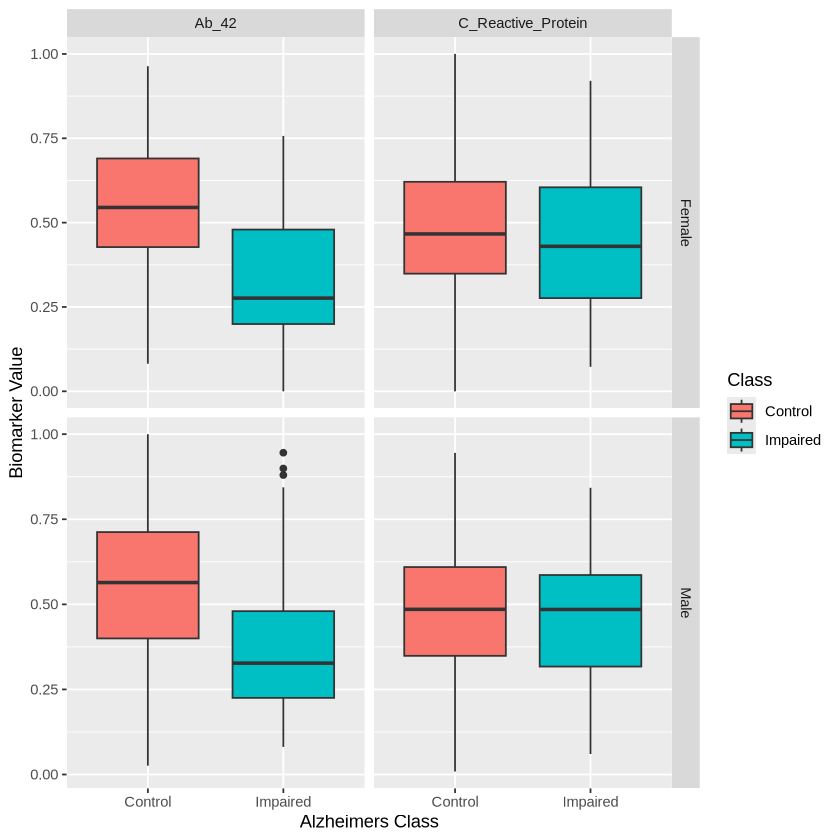

In [9]:
# Main Devleoper: Adam Walmsley

ggplot(plotting_data, aes(x = Class, y = Value, fill = Class)) +
    geom_boxplot() +
    facet_grid(male ~ Biomarker, scales = 'free_y') +
    labs(Title = 'Top 2 Biomarker by Variance', 
        x = 'Alzheimers Class',
        y = 'Biomarker Value')

From the plot above the values of the biomarker Ab_42 clearly show a difference in the Class of the patients. Gender less so. Also c_Reactive_protein seems much less promising as a useful predictor of class. This is a promising result nonetheless since we have confirmed the amounts of the values of some biomarkers likely will help us in predicting the class of patients and thus variable selection methods can be analyzed further. 

#### Methods: Plan

To conduct our analysis in hopes of answering the esearch question we will follow the steps below.
1. Split data into train and test set
2. Fit stepwise, ridge, lasso models on the training set
3. Using the chosen variables for each model, fit a logistic regression model on the training set
4. Evaluate all models on the test set
5. Compare all models on various metrics including AUC, F1 score, sensitivity, specificity, precision, accuracy, and model complexity (number of variables selected).

**Splitting The Data**

In [10]:
# Main Developer: Aadetri Tawara

set.seed(42)

# Split the data into 30% test and 70% training sets
# Stratifying by response variable because of class imbalance
data_split <- initial_split(dataset, prop = 0.70, strata = Class)
train_data <- training(data_split)
test_data  <- testing(data_split)

**Lasso Logistic Regression:**

In [11]:
# Main Developer: Aadetri Tawara

# Extract explanatory and response variables matrix
x_train <- model.matrix(Class ~ ., data = train_data)[, -1] 
y_train <- as.matrix(train_data$Class, ncol = 1)

x_test <- model.matrix(Class ~ ., data = test_data)[, -1] 
y_test <- as.matrix(test_data$Class, ncol = 1)

# Select lambda (lasso regularization coefficient) using 5 fold cross validation
cv_lasso <- cv.glmnet(x_train, y_train, 
                    family = "binomial", # binary response variable
                    alpha = 1,           # lasso regularization
                    nfolds = 5, 
                    type.measure = "auc")

# LASSO coefficients for the 1se lambda
coef_1se <- coef(cv_lasso, s = "lambda.1se")

# LASSO coefficients for min lambda value
coef_min <- coef(cv_lasso, s = "lambda.min")

In [12]:
# Main Developer: Aadetri Tawara

# Function to extract only non zero variables
get_nonzero <- function(coef_matrix) {
  df <- as.matrix(coef_matrix)
  # Filter for rows not equal to 0
  nonzero <- df[df[, 1] != 0, , drop = FALSE]
  return(nonzero)
}

cat("Min Lambda\n")
print(get_nonzero(coef_min))
cat("\n1se Lambda\n")
print(get_nonzero(coef_1se))

Min Lambda
                                          s1
(Intercept)                      -3.93561975
Cortisol                          0.28765622
Cystatin_C                       -2.59446773
ENA_78                           -0.57060397
Fibrinogen                        0.64037311
GRO_alpha                         0.81052078
Gamma_Interferon_induced_Monokin  1.15590612
IL_7                             -0.01980267
MCP_2                             0.27899046
MIP_1beta                         0.02191247
NT_proBNP                         1.29189499
PAI_1                             1.45541567
TRAIL_R3                          0.52918339
Thymus_Expressed_Chemokine_TECK   1.48946872
VEGF                             -3.88090954
tau                               5.61302579
Ab_42                            -1.53599794
GenotypeE4E4                      0.55301953

1se Lambda
                                         s1
(Intercept)                      -2.5979399
Cystatin_C                       -

Based on the final selected models displayed above, the 1se lambda model is going to be selected for the final analysis because it provides a more parsimonious set of predictors while maintaining alignment with established Alzheimer's literature (specifically regarding `tau` and `ab_42`).

In [20]:
# Main Developer: Aadetri Tawara

# Test set prediction probabilities
pred_probs <- predict(
    cv_lasso, 
    newx = x_test,
    type = "response",
    s = "lambda.1se" # simpler model's lambda selected
)

# Converting probabilities to classes
pred_class <- ifelse(pred_probs > 0.5, "Impaired", "Control")

raw_preds  <- as.vector(pred_class)
raw_actual <- as.vector(y_test)

# Convert to factor
target_levels <- c("Control", "Impaired") 
pred_fact   <- factor(raw_preds,  levels = target_levels)
actual_fact <- factor(raw_actual, levels = target_levels)

# Confusion matrix
conf_results <- confusionMatrix(pred_fact, actual_fact, positive = "Impaired")


In [21]:
# Main Developer: Aadetri Tawara

# Extracting performance metrics from confusion matrix
accuracy    <- conf_results$overall["Accuracy"]
sensitivity <- conf_results$byClass["Sensitivity"]
specificity <- conf_results$byClass["Specificity"]
precision   <- conf_results$byClass["Precision"]
f1_score    <- conf_results$byClass["F1"]

# Extracting AUC from glmnet for lambda.1se
lambda_idx <- which(cv_lasso$lambda == cv_lasso$lambda.1se)
auc_score <- cv_lasso$cvm[lambda_idx]

# Putting metrics in a table
metrics_table <- data.frame(
    Model = "Lasso",
    Metric = c("Accuracy", "Specificity", "Sensitivity", "Precision", "F1 Score", "AUC"),
    Value = c(accuracy, specificity, sensitivity, precision, f1_score, auc_score),
    row.names = NULL 
)

metrics_table

Model,Metric,Value
<chr>,<chr>,<dbl>
Lasso,Accuracy,0.7821782
Lasso,Specificity,0.9589041
Lasso,Sensitivity,0.3214286
Lasso,Precision,0.7500000
Lasso,F1 Score,0.4500000
Lasso,AUC,0.9345407


**Ridge Logistic Regression:**

In [15]:
# Main Developer: Kenrick Tan

cv_ridge <- cv.glmnet(
  x_train, y_train,
  family = "binomial",   # binary response
  alpha = 0,             # ridge regularization
  nfolds = 5,
  type.measure = "auc"
)

# Coefficients for lambda.min and lambda.1se
ridge_coef_min <- coef(cv_ridge, s = "lambda.min")
ridge_coef_1se <- coef(cv_ridge, s = "lambda.1se")

cat("Ridge Coefficients at lambda.min\n")
# print(ridge_coef_min)

cat("\nRidge Coefficients at lambda.1se\n")
# print(ridge_coef_1se)

Ridge Coefficients at lambda.min

Ridge Coefficients at lambda.1se


In [16]:
# Main Developer: Kenrick Tan

# Test set prediction probabilities
ridge_probs <- predict(
  cv_ridge,
  newx = x_test,
  type = "response",
  s = "lambda.1se"
)

# Convert probabilities to classes
ridge_pred_class <- ifelse(ridge_probs > 0.5, "Impaired", "Control")

ridge_raw_preds  <- as.vector(ridge_pred_class)
ridge_raw_actual <- as.vector(y_test)

# Convert to factor
target_levels <- c("Control", "Impaired")
ridge_pred_fact   <- factor(ridge_raw_preds, levels = target_levels)
ridge_actual_fact <- factor(ridge_raw_actual, levels = target_levels)

# Confusion matrix
ridge_conf_results <- confusionMatrix(
  ridge_pred_fact,
  ridge_actual_fact,
  positive = "Impaired"
)

In [ ]:
# Main Developer: Kenrick Tan

ridge_accuracy    <- ridge_conf_results$overall["Accuracy"]
ridge_sensitivity <- ridge_conf_results$byClass["Sensitivity"]
ridge_specificity <- ridge_conf_results$byClass["Specificity"]
ridge_precision   <- ridge_conf_results$byClass["Precision"]
ridge_f1_score    <- ridge_conf_results$byClass["F1"]

# Extract AUC from glmnet 
ridge_lambda_idx <- which(cv_ridge$lambda == cv_ridge$lambda.1se)
ridge_auc_score <- cv_ridge$cvm[ridge_lambda_idx]

# Put the metrics into a table
ridge_metrics_table <- data.frame(
  Model = "Ridge",
  Metric = c("Accuracy", "Specificity", "Sensitivity", "Precision", "F1 Score", "AUC"),
  Value = c(
    ridge_accuracy,
    ridge_specificity,
    ridge_sensitivity,
    ridge_precision,
    ridge_f1_score,
    ridge_auc_score
  ),
    row.names = NULL
)

ridge_metrics_table

Model,Metric,Value
<chr>,<chr>,<dbl>
Ridge,Accuracy,0.7623762
Ridge,Specificity,0.9863014
Ridge,Sensitivity,0.1785714
Ridge,Precision,0.8333333
Ridge,F1 Score,0.2941176
Ridge,AUC,0.8954532


**Logistic Regression with stepwise variable selection:**


In [ ]:
# Main Developer: An Trinh

# Fit full model using all predictors
full_model <- glm(Class ~ ., data = train_data, family = "binomial")


# Limit steps in favor of runtime

step_model <- stepAIC(full_model, direction = "both", trace = FALSE, steps = 50)


In [ ]:
# Main Developer: An Trinh

# Get the variable selected from final stepwise model
get_selected_vars <- function(model) {
  vars <- names(coef(model))
  # remove intercept
  vars <- vars[vars != "(Intercept)"]
  return(vars)
}

cat("Selected Variables (Stepwise):\n")
print(get_selected_vars(step_model))

In [ ]:
# Main Developer: An Trinh

# Predict probabilities on test set
step_probs <- predict(
  step_model,
  newdata = test_data,
  type = "response"
)

# Threshold = 0.5
step_pred_class <- ifelse(step_probs > 0.5, "Impaired", "Control")

# Convert to vectors
step_raw_preds  <- as.vector(step_pred_class)
step_raw_actual <- as.vector(test_data$Class)

# Convert to factors for evaluation
target_levels <- c("Control", "Impaired")
step_pred_fact   <- factor(step_raw_preds,  levels = target_levels)
step_actual_fact <- factor(step_raw_actual, levels = target_levels)


# Confusion matrix
step_conf_results <- confusionMatrix(
  step_pred_fact,
  step_actual_fact,
  positive = "Impaired"
)

In [ ]:
# Main Developer: An Trinh

step_accuracy    <- step_conf_results$overall["Accuracy"]
step_sensitivity <- step_conf_results$byClass["Sensitivity"]
step_specificity <- step_conf_results$byClass["Specificity"]
step_precision   <- step_conf_results$byClass["Precision"]
step_f1_score    <- step_conf_results$byClass["F1"]


# Compute AUC on test set
step_roc_obj <- roc(actual_fact, as.vector(step_probs))
step_auc_test <- auc(step_roc_obj)


# Combine metrics into table

step_metrics_table <- data.frame(
  Model = "Stepwise",
  Metric = c("Accuracy", "Specificity", "Sensitivity", "Precision", "F1 Score", "AUC"),
  Value = c(step_accuracy, step_specificity, step_sensitivity, step_precision, step_f1_score, step_auc_test),
  row.names = NULL
)

metrics_table

## Discussion

## References

Goerdten, Jantje, et al. “Statistical methods for dementia risk prediction and recommendations for future work: A systematic review.” Alzheimer’s &amp; Dementia: Translational Research &amp; Clinical Interventions, vol. 5, no. 1, Jan. 2019, pp. 563–569, https://doi.org/10.1016/j.trci.2019.08.001. 

Subramanian, Jyothi, and Richard Simon. “Overfitting in prediction models – is it a problem only in high dimensions?” Contemporary Clinical Trials, vol. 36, no. 2, Nov. 2013, pp. 636–641, https://doi.org/10.1016/j.cct.2013.06.011. 

Iaccarino, Leonardo, et al. “Diagnostic biomarkers of amyloid and tau pathology in alzheimer’s disease: An overview of tests for clinical practice in the United States and Europe.” The Journal of Prevention of Alzheimer’s Disease, vol. 10, no. 3, Sept. 2023, pp. 426–442, https://doi.org/10.14283/jpad.2023.43. 

Craig-Schapiro, Rebecca, et al. “Multiplexed immunoassay panel identifies novel CSF biomarkers for alzheimer’s disease diagnosis and prognosis.” PLoS ONE, vol. 6, no. 4, 19 Apr. 2011, https://doi.org/10.1371/journal.pone.0018850. 